In [90]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, roc_curve, auc)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

import cv2
from PIL import Image
import itertools

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))

TensorFlow version: 2.19.0
GPU available: True


In [91]:
!pip install imbalanced-learn -q

# Data Loading & EDA

In [92]:

#  CELL 2: Data Loading & Exploratory Data Analysis

DATA_DIR = Path("/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT")
CLASSES   = ['benign', 'malignant', 'normal']
IMG_SIZE  = (128, 128)

# ── collect image paths (skip mask files) ──────────────────
data = []
for cls in CLASSES:
    folder = DATA_DIR / cls
    for fp in sorted(folder.glob("*.png")):
        if "mask" not in fp.name.lower():
            data.append({'path': str(fp), 'label': cls})

df = pd.DataFrame(data)
print(f"Total images: {len(df)}")
print(df['label'].value_counts())

Total images: 780
label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


#  Class Distribution Visualization

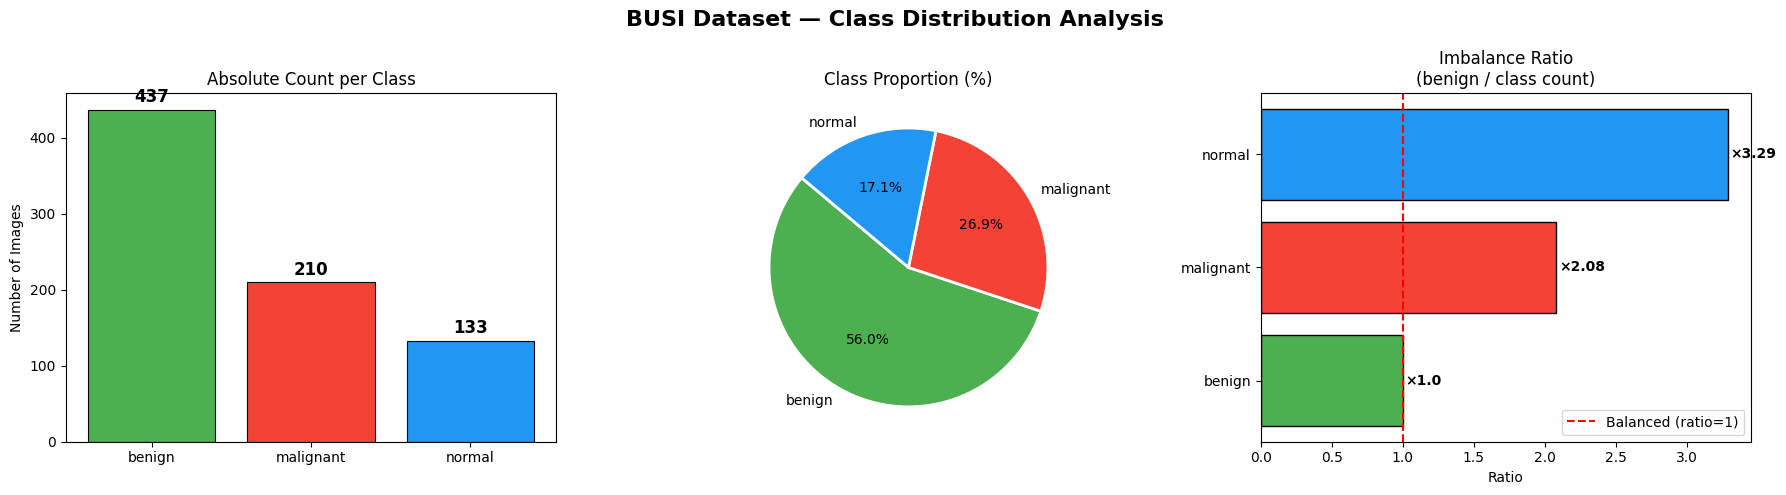


📌 Imbalance Summary:
  Benign   : 437  (majority)
  Malignant: 210 — ratio: ×2.08
  Normal   : 133  — ratio: ×3.29


In [93]:
counts = df['label'].value_counts().reindex(CLASSES)
colors = ['#4CAF50', '#F44336', '#2196F3']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("BUSI Dataset — Class Distribution Analysis", fontsize=16, fontweight='bold')

# Bar chart
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title("Absolute Count per Class")
axes[0].set_ylabel("Number of Images")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title("Class Proportion (%)")

# Imbalance ratio bar
max_count = counts.max()
ratios = (max_count / counts).round(2)
axes[2].barh(ratios.index, ratios.values, color=colors, edgecolor='black')
axes[2].axvline(1.0, color='red', linestyle='--', label='Balanced (ratio=1)')
axes[2].set_title("Imbalance Ratio\n(benign / class count)")
axes[2].set_xlabel("Ratio")
for i, v in enumerate(ratios.values):
    axes[2].text(v + 0.02, i, f'×{v}', va='center', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📌 Imbalance Summary:")
print(f"  Benign   : {counts['benign']}  (majority)")
print(f"  Malignant: {counts['malignant']} — ratio: ×{max_count/counts['malignant']:.2f}")
print(f"  Normal   : {counts['normal']}  — ratio: ×{max_count/counts['normal']:.2f}")

# Sample Images per Class

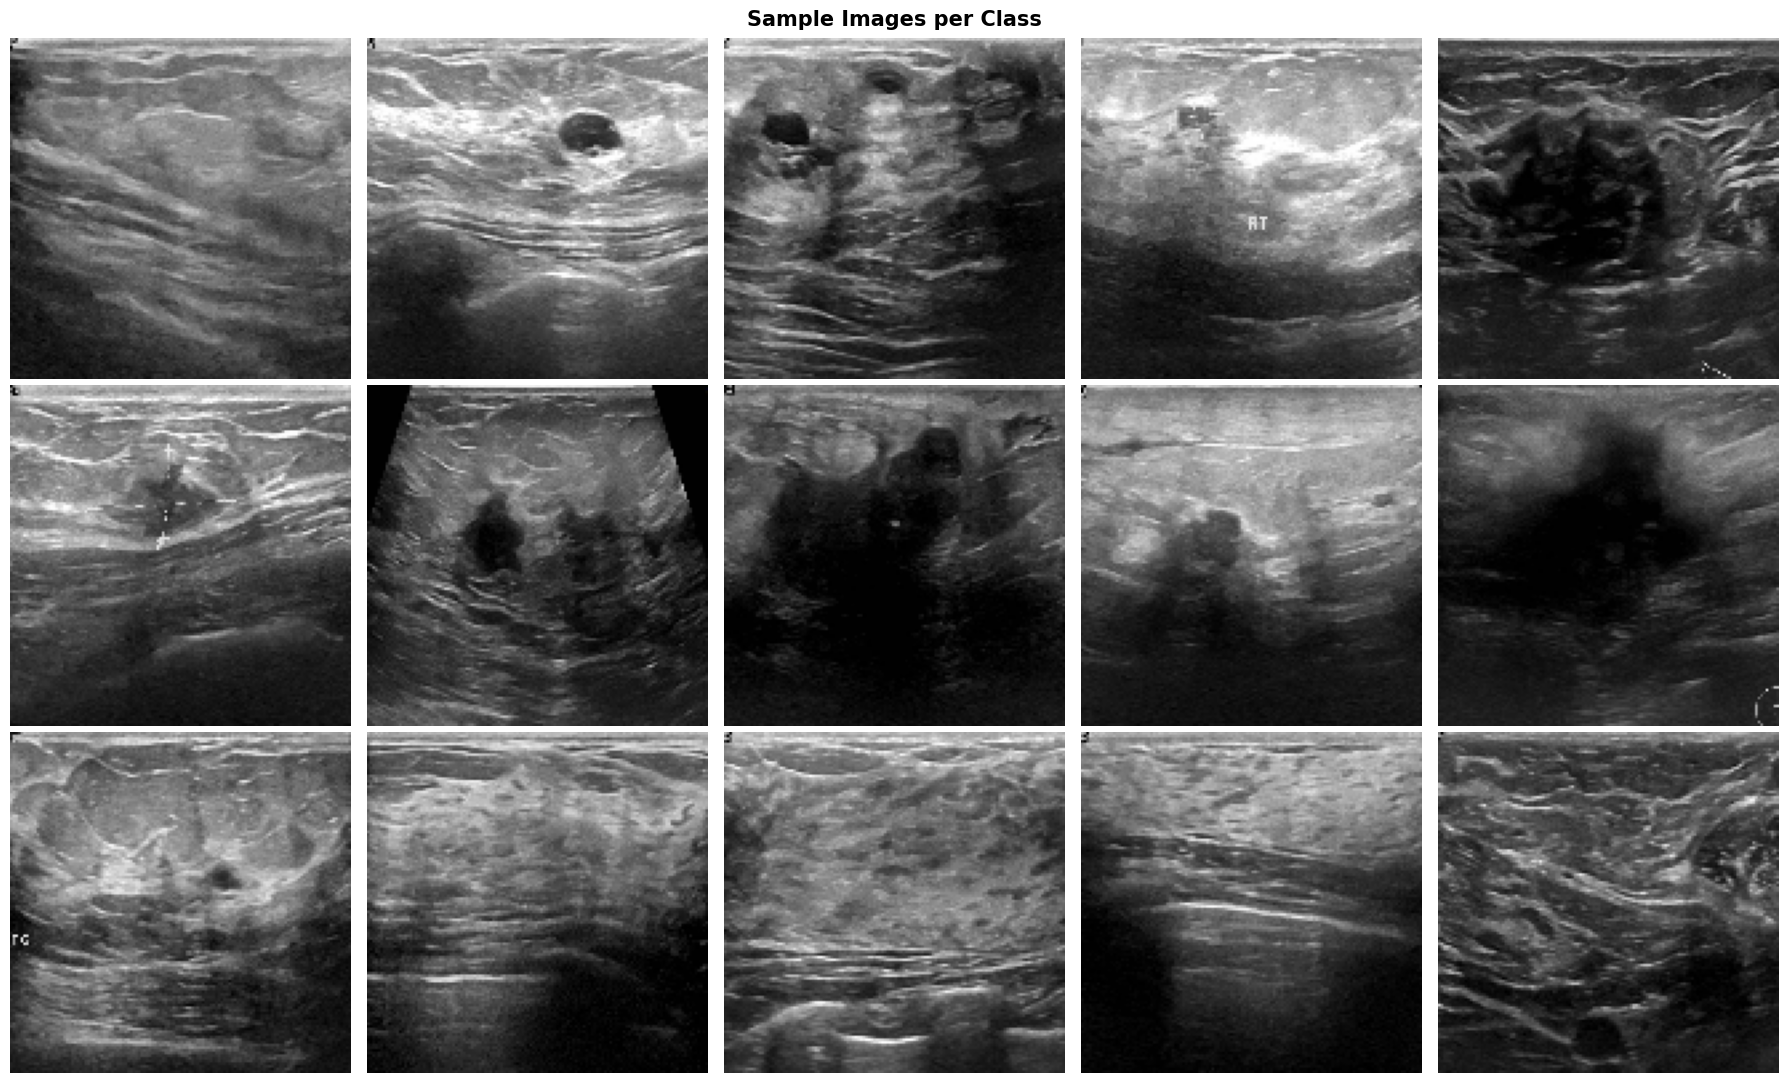

In [94]:
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
fig.suptitle("Sample Images per Class", fontsize=15, fontweight='bold')

for row, cls in enumerate(CLASSES):
    samples = df[df['label'] == cls].sample(5, random_state=SEED)
    for col, (_, row_data) in enumerate(samples.iterrows()):
        img = cv2.imread(row_data['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        axes[row][col].imshow(img, cmap='gray' if img.ndim == 2 else None)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls.upper(), fontsize=11,
                                       fontweight='bold', rotation=90,
                                       labelpad=10, va='center')
            axes[row][col].yaxis.set_label_position('left')
            axes[row][col].tick_params(left=False)

plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

# Train/Val/Test Split

In [95]:
from sklearn.model_selection import train_test_split

label2idx = {c: i for i, c in enumerate(CLASSES)}
df['label_idx'] = df['label'].map(label2idx)

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label_idx'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label_idx'], random_state=SEED)

print(f"Train : {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print("\nTrain class distribution:")
print(train_df['label'].value_counts())
print(val_df['label'].value_counts())
print(test_df['label'].value_counts())

Train : 546  |  Val: 117  |  Test: 117

Train class distribution:
label
benign       306
malignant    147
normal        93
Name: count, dtype: int64
label
benign       65
malignant    32
normal       20
Name: count, dtype: int64
label
benign       66
malignant    31
normal       20
Name: count, dtype: int64


# Create a Balanced Test Set for Fair Evaluation

In [96]:
# from sklearn.utils import resample

# # Find minimum class count in test set
# min_test_count = test_df['label'].value_counts().min()
# print(f"Balancing test set to {min_test_count} samples per class")

# balanced_test_parts = []
# for cls in CLASSES:
#     cls_df = test_df[test_df['label'] == cls]
#     cls_balanced = resample(cls_df, 
#                             n_samples=min_test_count,
#                             random_state=SEED, 
#                             replace=False)
#     balanced_test_parts.append(cls_balanced)

# test_df_balanced = pd.concat(balanced_test_parts).sample(frac=1, random_state=SEED)
# print(f"Balanced test set: {len(test_df_balanced)} samples")
# print(test_df_balanced['label'].value_counts())

# X_test_bal, y_test_bal = load_images(test_df_balanced)

# Image Loading Utility

In [97]:
def load_images(dataframe, img_size=IMG_SIZE):
    """Load images from paths and return (X, y) arrays."""
    X, y = [], []
    for _, row in dataframe.iterrows():
        img = cv2.imread(row['path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        img = preprocess_input(img.astype(np.float32))  # correct normalization
        X.append(img)
        y.append(row['label_idx'])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

print("Loading images...")
X_train, y_train = load_images(train_df)
X_val,   y_val   = load_images(val_df)
X_test,  y_test  = load_images(test_df)
print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}")

Loading images...
X_train: (546, 128, 128, 3)  |  X_val: (117, 128, 128, 3)  |  X_test: (117, 128, 128, 3)


In [98]:
import tensorflow as tf

def focal_loss(gamma=2., alpha=.25):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), 3)
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        loss = alpha * tf.pow(1 - p_t, gamma) * ce
        return loss
    return loss

# CNN Model Definition

In [99]:
 # (Transfer Learning — MobileNetV2)

def build_model(num_classes=3, dropout_rate=0.4):
    base = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = False        # freeze base initially

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate / 2),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=focal_loss(),
        metrics=['accuracy']
    )
    return model

model_baseline = build_model()
model_baseline.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

# STRATEGY 1 — Class Weights

Class Weights:
  benign       → weight = 0.5948
  malignant    → weight = 1.2381
  normal       → weight = 1.9570


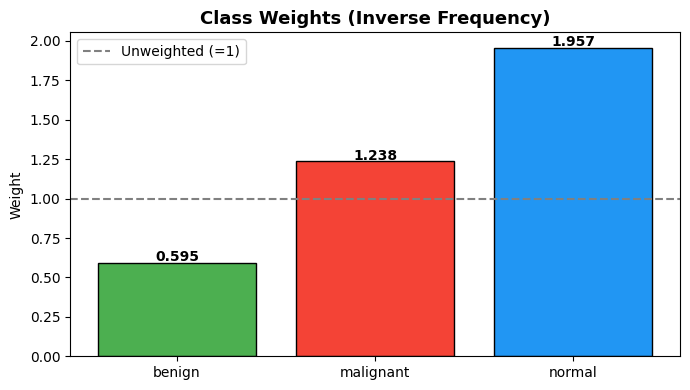

In [100]:
#  Penalises the model more for misclassifying minority classes.

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class Weights:")
for idx, cls in enumerate(CLASSES):
    print(f"  {cls:12s} → weight = {class_weight_dict[idx]:.4f}")

# Visualise class weights
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASSES, class_weights_array, color=['#4CAF50', '#F44336', '#2196F3'], edgecolor='black')
ax.set_title("Class Weights (Inverse Frequency)", fontsize=13, fontweight='bold')
ax.set_ylabel("Weight")
for bar, w in zip(bars, class_weights_array):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{w:.3f}', ha='center', fontweight='bold')
ax.axhline(1.0, color='gray', linestyle='--', label='Unweighted (=1)')
ax.legend()
plt.tight_layout()
plt.savefig("class_weights.png", dpi=150)
plt.show()

# STRATEGY 2 — Augmentation-Based Oversampling

In [128]:
#  Augments minority classes so every class has ~benign count.

from tensorflow.keras.preprocessing.image import img_to_array, array_to_img

TARGET_COUNT = max(Counter(y_train).values())

aug_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
)

def augment_class(X_cls, y_cls, target_n, seed=SEED):
    """Generate augmented samples until target_n reached."""
    extra_X, extra_y = [], []
    label = y_cls[0]
    while len(X_cls) + len(extra_X) < target_n:
        idx = random.randint(0, len(X_cls) - 1)
        img = X_cls[idx:idx+1]          # shape (1,H,W,3)
        aug_iter = aug_gen.flow(img, batch_size=1, seed=seed)
        aug_img  = next(aug_iter)[0]
        extra_X.append(aug_img)
        extra_y.append(label)
    return np.array(extra_X, dtype=np.float32), np.array(extra_y, dtype=np.int32)

X_train_aug, y_train_aug = X_train.copy(), y_train.copy()

for idx, cls in enumerate(CLASSES):
    mask = y_train == idx
    cls_X, cls_y = X_train[mask], y_train[mask]
    current = len(cls_X)
    if current < TARGET_COUNT:
        eX, ey = augment_class(cls_X, cls_y, TARGET_COUNT)
        X_train_aug = np.concatenate([X_train_aug, eX])
        y_train_aug = np.concatenate([y_train_aug, ey])
        print(f"  {cls:12s}: {current} → {current + len(eX)} (added {len(eX)} augmented)")
    else:
        print(f"  {cls:12s}: {current} (no augmentation needed)")

# Shuffle
perm = np.random.permutation(len(X_train_aug))
X_train_aug, y_train_aug = X_train_aug[perm], y_train_aug[perm]
print(f"\nAugmented train set: {X_train_aug.shape}  | Class dist: {Counter(y_train_aug)}")

  benign      : 306 (no augmentation needed)
  malignant   : 147 → 306 (added 159 augmented)
  normal      : 93 → 306 (added 213 augmented)

Augmented train set: (918, 128, 128, 3)  | Class dist: Counter({np.int32(1): 306, np.int32(0): 306, np.int32(2): 306})


# STRATEGY 3 — SMOTE on Flattened Features

Before SMOTE: Counter({np.int32(0): 306, np.int32(1): 147, np.int32(2): 93})
After  SMOTE: Counter({np.int32(0): 306, np.int32(2): 306, np.int32(1): 306})

Running PCA + t-SNE for visualisation...


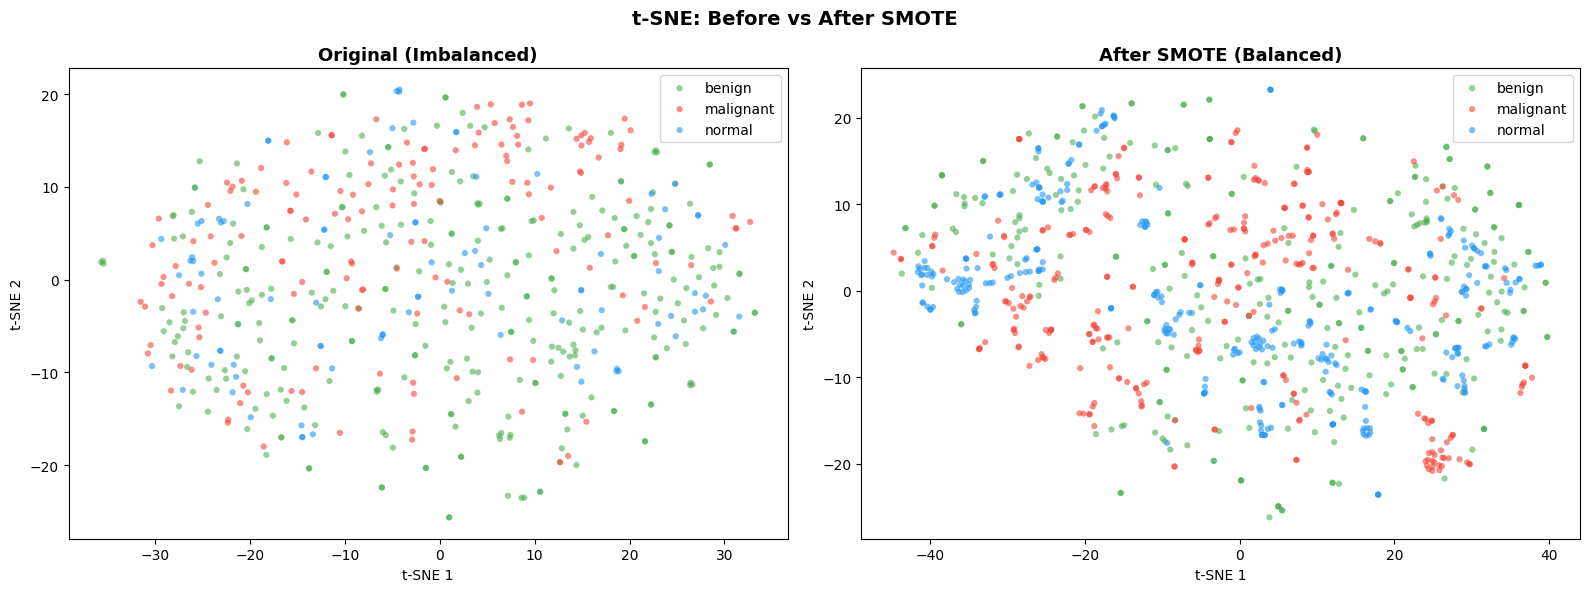

In [102]:
from imblearn.over_sampling import SMOTE

# Flatten images for SMOTE (it works on 1D feature vectors)
n_train = X_train.shape[0]
X_train_flat = X_train.reshape(n_train, -1)   # (N, 128*128*3)

smote = SMOTE(random_state=SEED)
X_smote_flat, y_smote = smote.fit_resample(X_train_flat, y_train)

# Reshape back to image format
X_train_smote = X_smote_flat.reshape(-1, *IMG_SIZE, 3).astype(np.float32)
print(f"Before SMOTE: {Counter(y_train)}")
print(f"After  SMOTE: {Counter(y_smote)}")

# ── t-SNE Visualization (before vs after) ──────────────────
# Use PCA first to reduce dims before t-SNE (speeds it up a lot)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("\nRunning PCA + t-SNE for visualisation...")
pca = PCA(n_components=50, random_state=SEED)
feats_orig     = pca.fit_transform(X_train_flat)
feats_smote_50 = pca.transform(X_smote_flat)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=500)
orig_2d   = tsne.fit_transform(feats_orig)

tsne2 = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=500)
smote_2d  = tsne2.fit_transform(feats_smote_50[:1200])   # subsample for speed
y_smote_sub = y_smote[:1200]

palette = {0: '#4CAF50', 1: '#F44336', 2: '#2196F3'}
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (feats_2d, labels, title) in zip(axes, [
    (orig_2d,  y_train,     "Original (Imbalanced)"),
    (smote_2d, y_smote_sub, "After SMOTE (Balanced)")
]):
    for cls_idx, cls_name in enumerate(CLASSES):
        mask = labels == cls_idx
        ax.scatter(feats_2d[mask, 0], feats_2d[mask, 1],
                   c=palette[cls_idx], label=cls_name,
                   alpha=0.6, s=20, edgecolors='none')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(); ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")

plt.suptitle("t-SNE: Before vs After SMOTE", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("tsne_smote.png", dpi=150)
plt.show()

# Training Helper

In [103]:
from sklearn.metrics import f1_score

class F1Callback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        y_pred = self.model.predict(X_val)
        y_pred = np.argmax(y_pred, axis=1)
        f1 = f1_score(y_val, y_pred, average='macro')
        print(f"\nVal Macro F1: {f1:.4f}")

In [104]:
EPOCHS     = 30
BATCH_SIZE = 32

early_stop = callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss')
lr_reduce  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

def train_model(X_tr, y_tr, label, class_wt=None, epochs=EPOCHS):
    print(f"\n{'='*55}")
    print(f"  Training: {label}")
    print(f"{'='*55}")
    m = build_model()
    hist = m.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        class_weight=class_wt,
        callbacks=[early_stop, lr_reduce,F1Callback()],
        verbose=1
    )
    return m, hist

# Train all 3 strategies + 1 baseline

In [129]:
# Baseline — no imbalance handling
model_base, hist_base = train_model(X_train, y_train,
                                    label="Baseline (No Handling)")

# Strategy 1 — Class Weights
model_cw, hist_cw = train_model(X_train, y_train,
                                label="Strategy 1: Class Weights",
                                class_wt=class_weight_dict)

# Strategy 2 — Augmentation Oversampling
model_aug, hist_aug = train_model(X_train_aug, y_train_aug,
                                  label="Strategy 2: Augmentation Oversampling")

# Strategy 3 — SMOTE 
model_smote, hist_smote = train_model(X_train_smote, y_smote,
                                      label="Strategy 3: SMOTE Oversampling")

# Strategy 4 — Combined (Augmentation + Class Weights)
model_combo, hist_combo = train_model(X_train_aug, y_train_aug,
                                      label="Strategy 4: Augmentation + Class Weights",
                                      class_wt=class_weight_dict)
print("\n✅ All models trained!")


  Training: Baseline (No Handling)
Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step step - accuracy: 0.4200 - loss: 0.2

Val Macro F1: 0.4123
18/18 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.4219 - loss: 0.2338 - val_accuracy: 0.6154 - val_loss: 0.1018 - learning_rate: 1.0000e-04
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/stepep - accuracy: 0.5387 - loss: 0.144

Val Macro F1: 0.4198
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5340 - loss: 0.1467 - val_accuracy: 0.6325 - val_loss: 0.0904 - learning_rate: 1.0000e-04
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/stepep - accuracy: 0.6336 - loss: 0.114

Val Macro F1: 0.5268
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6339 - loss: 0.1142 - val_accuracy: 0.6667 - val_loss: 0.0817 - learning_rate: 1.0000e-04
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/stepep - accuracy: 0.6527 - loss: 0.092

Val Macro F1: 0.5778
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6528 - loss: 0.0928 - val_accuracy: 0.7009 - val_loss: 0

# Training Curves Comparison

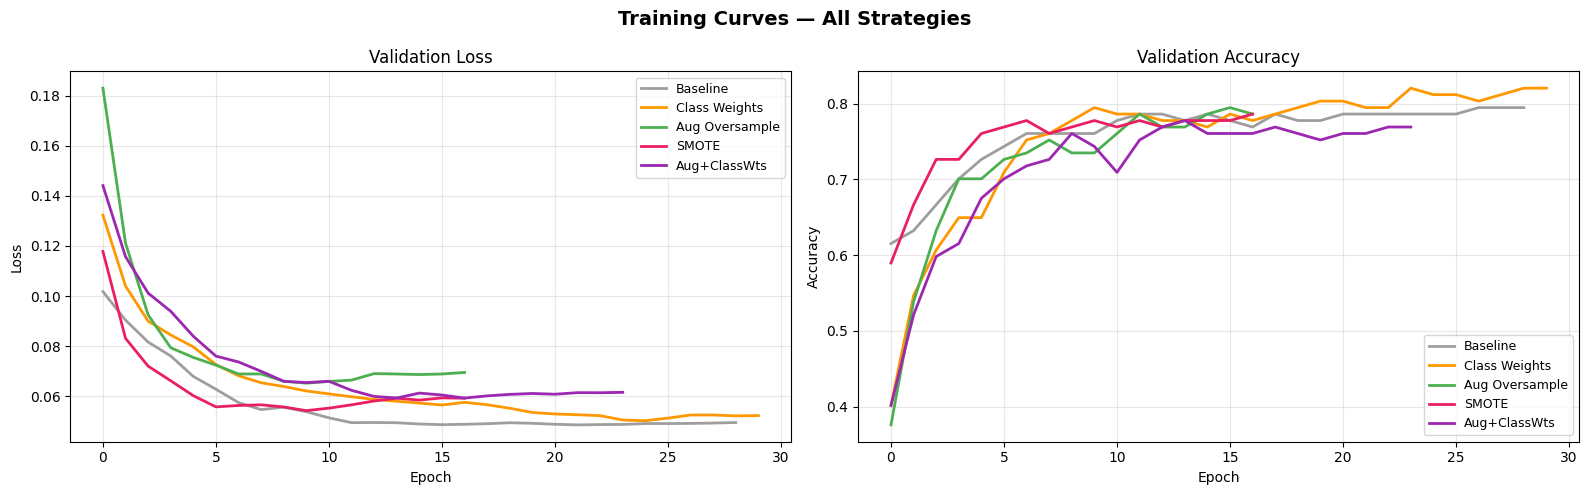

In [130]:
histories = {
    'Baseline'      : hist_base,
    'Class Weights' : hist_cw,
    'Aug Oversample': hist_aug,
    'SMOTE'         : hist_smote,      
    'Aug+ClassWts'  : hist_combo,
}
line_colors = ['#9E9E9E', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Training Curves — All Strategies", fontsize=14, fontweight='bold')

for (name, h), color in zip(histories.items(), line_colors):
    axes[0].plot(h.history['val_loss'],     label=name, color=color, linewidth=2)
    axes[1].plot(h.history['val_accuracy'], label=name, color=color, linewidth=2)

for ax, title, ylabel in zip(axes,
                              ['Validation Loss', 'Validation Accuracy'],
                              ['Loss', 'Accuracy']):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

# Evaluation Function

In [131]:
def evaluate_model(model, X_te, y_te, model_name):
    y_pred_prob = model.predict(X_te, verbose=0)
    y_pred      = np.argmax(y_pred_prob, axis=1)

    acc = np.mean(y_pred == y_te)
    p, r, f1, _ = precision_recall_fscore_support(y_te, y_pred,
                                                   average='macro',
                                                   zero_division=0)
    p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(
        y_te, y_pred, labels=[0,1,2], zero_division=0)

    print(f"\n{'─'*50}")
    print(f"  {model_name}")
    print(f"{'─'*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {p:.4f}  |  Recall: {r:.4f}  |  F1: {f1:.4f}  (macro)")
    print("\n" + classification_report(y_te, y_pred,
          target_names=CLASSES, zero_division=0))

    return {
        'name'    : model_name,
        'acc'     : acc, 'precision': p, 'recall': r, 'f1': f1,
        'y_pred'  : y_pred, 'y_pred_prob': y_pred_prob,
        'p_cls'   : p_cls, 'r_cls': r_cls, 'f1_cls': f1_cls
    }

results = {}
for name, m in [('Baseline',       model_base),
                ('Class Weights',  model_cw),
                ('Aug Oversample', model_aug),
                ('Smote ',  model_smote),
                ('Aug+ClassWts',   model_combo)]:
    results[name] = evaluate_model(m, X_test, y_test, name)


──────────────────────────────────────────────────
  Baseline
──────────────────────────────────────────────────
  Accuracy : 0.7692
  Precision: 0.7706  |  Recall: 0.7542  |  F1: 0.7616  (macro)

              precision    recall  f1-score   support

      benign       0.79      0.80      0.80        66
   malignant       0.69      0.71      0.70        31
      normal       0.83      0.75      0.79        20

    accuracy                           0.77       117
   macro avg       0.77      0.75      0.76       117
weighted avg       0.77      0.77      0.77       117


──────────────────────────────────────────────────
  Class Weights
──────────────────────────────────────────────────
  Accuracy : 0.7949
  Precision: 0.7838  |  Recall: 0.7635  |  F1: 0.7712  (macro)

              precision    recall  f1-score   support

      benign       0.80      0.85      0.82        66
   malignant       0.88      0.74      0.81        31
      normal       0.67      0.70      0.68        20



# Confusion Matrices for All Strategies

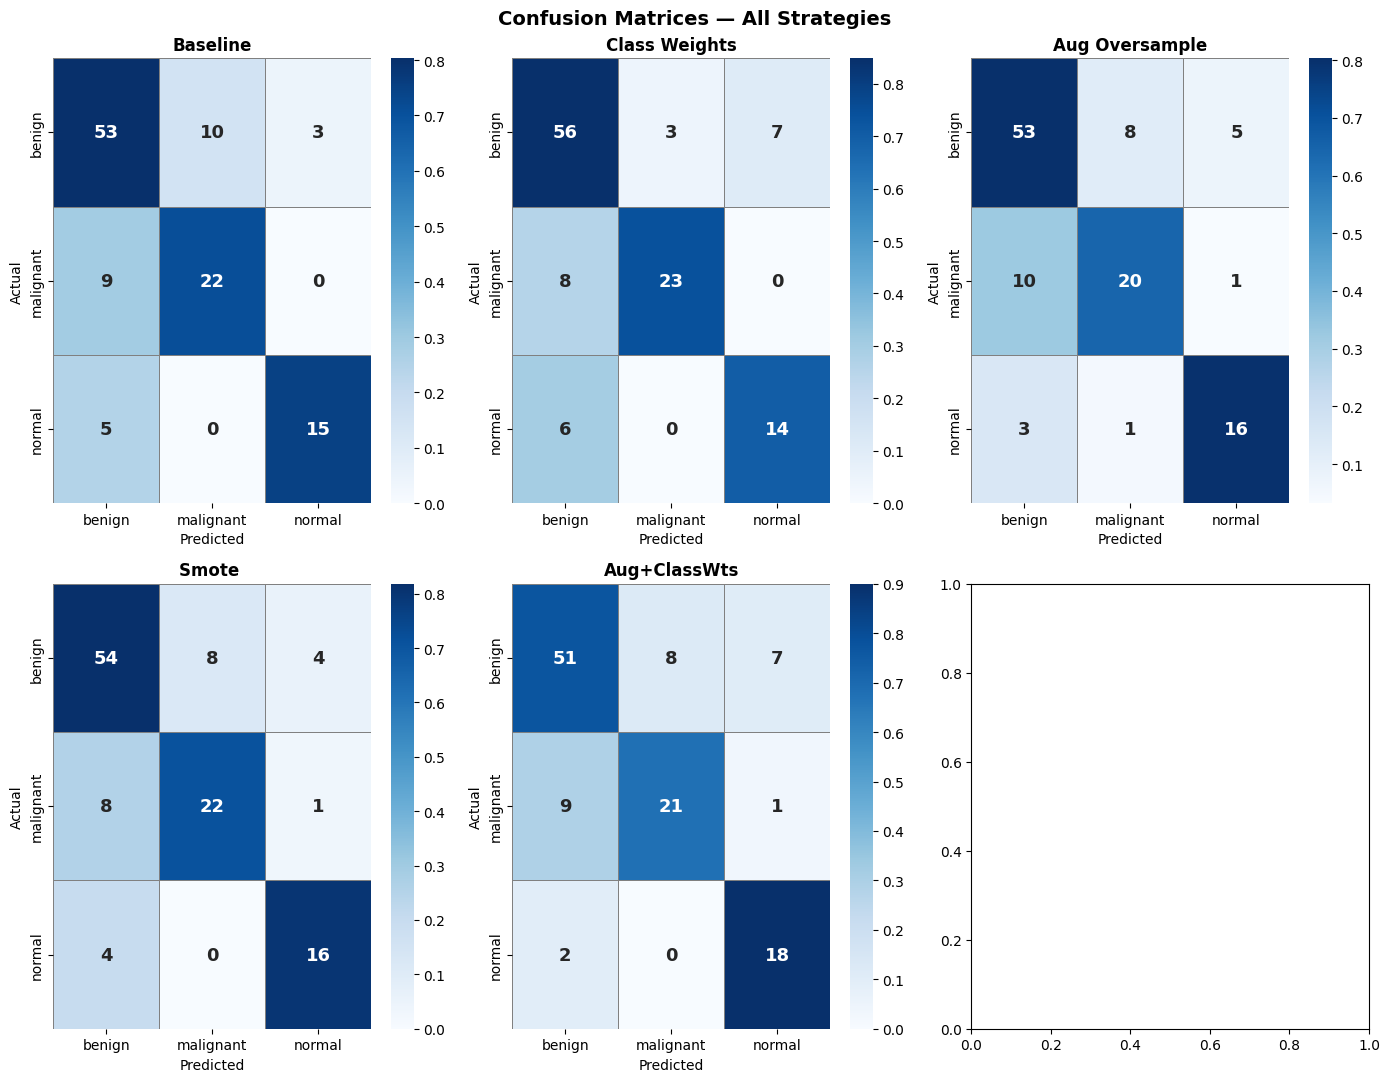

In [132]:
fig, axes = plt.subplots(2, 3, figsize=(14, 11))
fig.suptitle("Confusion Matrices — All Strategies", fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flat, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm, fmt='d', ax=ax,
                cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='gray',
                annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

#  Metrics Comparison — Bar Chart

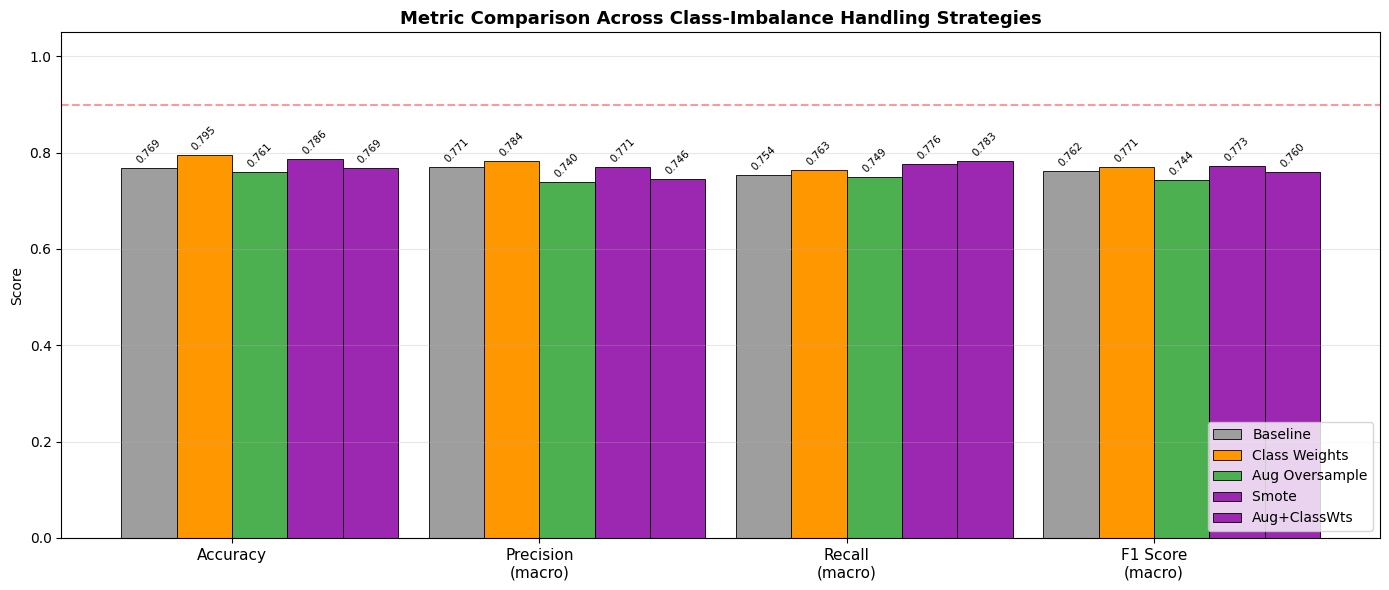

In [133]:
metrics = ['acc', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision\n(macro)', 'Recall\n(macro)', 'F1 Score\n(macro)']
strategy_names = list(results.keys())
colors_strat = ['#9E9E9E', '#FF9800', '#4CAF50', '#9C27B0','#9C27B0']

x = np.arange(len(metrics))
width = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, color) in enumerate(zip(strategy_names, colors_strat)):
    vals = [results[name][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name, color=color,
                  edgecolor='black', linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=45)

ax.set_xticks(x + 1.5*width); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_title("Metric Comparison Across Class-Imbalance Handling Strategies",
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.axhline(0.9, color='red', linestyle='--', alpha=0.4, label='0.9 threshold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=150)
plt.show()

#  Per-Class F1 Score Heatmap

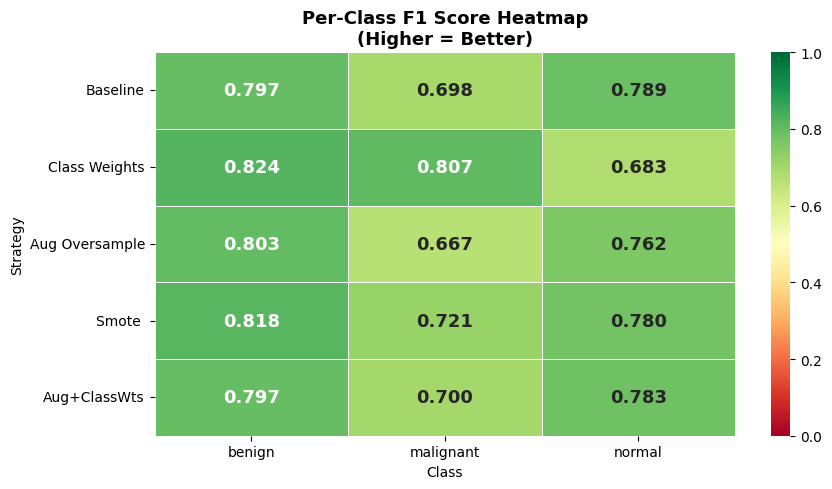


Per-Class F1 Score Table:
                benign  malignant  normal
Baseline         0.797      0.698   0.789
Class Weights    0.824      0.807   0.683
Aug Oversample   0.803      0.667   0.762
Smote            0.818      0.721   0.780
Aug+ClassWts     0.797      0.700   0.783


In [134]:
f1_matrix = np.array([results[n]['f1_cls'] for n in strategy_names])
f1_df = pd.DataFrame(f1_matrix, index=strategy_names, columns=CLASSES)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5,
            annot_kws={"size": 13, "weight": "bold"}, ax=ax)
ax.set_title("Per-Class F1 Score Heatmap\n(Higher = Better)", fontsize=13, fontweight='bold')
ax.set_xlabel("Class"); ax.set_ylabel("Strategy")
plt.tight_layout()
plt.savefig("perclass_f1_heatmap.png", dpi=150)
plt.show()

print("\nPer-Class F1 Score Table:")
print(f1_df.round(3).to_string())

# ROC Curves — Best Strategy

Best strategy by macro F1: Smote 


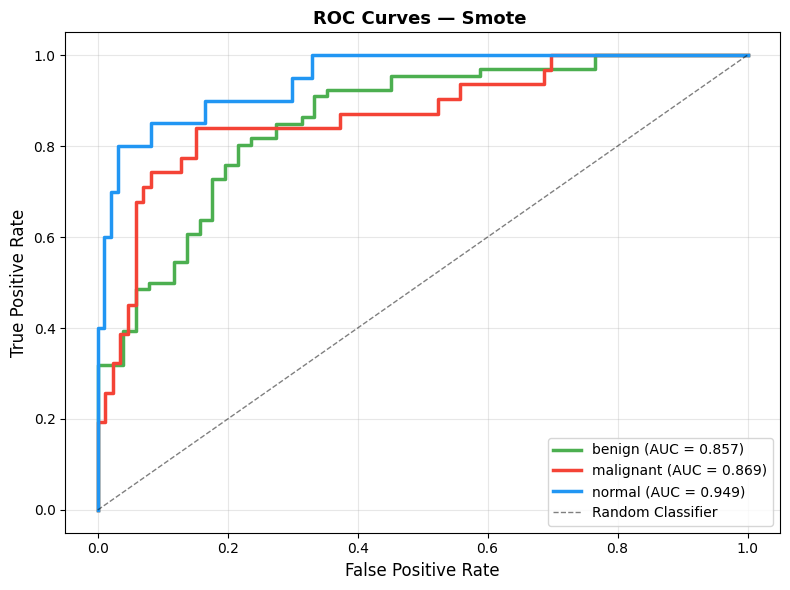

In [135]:
best_name   = max(results, key=lambda k: results[k]['f1'])
best_result = results[best_name]
print(f"Best strategy by macro F1: {best_name}")

y_test_bin    = label_binarize(y_test, classes=[0, 1, 2])
y_pred_prob   = best_result['y_pred_prob']

fig, ax = plt.subplots(figsize=(8, 6))
class_colors = ['#4CAF50', '#F44336', '#2196F3']

for i, (cls, color) in enumerate(zip(CLASSES, class_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{cls} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC Curves — {best_name}", fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()

In [137]:
#  CELL 19: Final Summary Table + Takeaway

summary_df = pd.DataFrame([{
    'Strategy'       : n,
    'Accuracy'       : f"{v['acc']:.4f}",
    'Precision(mac)' : f"{v['precision']:.4f}",
    'Recall(mac)'    : f"{v['recall']:.4f}",
    'F1(macro)'      : f"{v['f1']:.4f}",
} for n, v in results.items()])

print("\n" + "="*70)
print("         FINAL RESULTS SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Highlight best
best_f1_idx   = summary_df['F1(macro)'].astype(float).idxmax()
best_rec_idx  = summary_df['Recall(mac)'].astype(float).idxmax()
best_pre_idx  = summary_df['Precision(mac)'].astype(float).idxmax()

print(f"\n Best F1 (macro) : {summary_df.loc[best_f1_idx, 'Strategy']}"
      f"  -  F1 = {summary_df.loc[best_f1_idx, 'F1(macro)']}")
print(f" Best Recall     : {summary_df.loc[best_rec_idx, 'Strategy']}"
      f"  -  Recall = {summary_df.loc[best_rec_idx, 'Recall(mac)']}")
print(f" Best Precision     : {summary_df.loc[best_pre_idx, 'Strategy']}"
      f"  -  Precision = {summary_df.loc[best_pre_idx, 'Precision(mac)']}")


         FINAL RESULTS SUMMARY
      Strategy Accuracy Precision(mac) Recall(mac) F1(macro)
      Baseline   0.7692         0.7706      0.7542    0.7616
 Class Weights   0.7949         0.7838      0.7635    0.7712
Aug Oversample   0.7607         0.7400      0.7494    0.7439
        Smote    0.7863         0.7711      0.7760    0.7733
  Aug+ClassWts   0.7692         0.7463      0.7834    0.7598

 Best F1 (macro) : Smote   -  F1 = 0.7733
 Best Recall     : Aug+ClassWts  -  Recall = 0.7834
 Best Precision     : Class Weights  -  Precision = 0.7838


## Methodology

### 1. Dataset Preparation

The breast ultrasound dataset was organized into three diagnostic classes: benign, malignant, and normal. The dataset was divided into three subsets for model development and evaluation: training, validation, and testing. The training set was used for model learning, the validation set for monitoring performance and preventing overfitting, and the test set for final unbiased evaluation.

Each ultrasound image was preprocessed before training. Images were read from disk, converted from BGR to RGB format, resized to 128 × 128 pixels, and normalized using the MobileNetV2 preprocessing function to match the input distribution expected by the pretrained network.

---

### 2. Model Architecture

A transfer learning approach was adopted using MobileNetV2, a lightweight convolutional neural network pretrained on ImageNet. The convolutional backbone of MobileNetV2 was kept frozen to preserve the general visual features learned during pretraining.

On top of this backbone, a custom classification head was added consisting of:

- A **Global Average Pooling** layer to reduce spatial dimensions
- **Batch Normalization** for training stability
- Two **fully connected layers** with ReLU activation
- **Dropout layers** for regularization and overfitting prevention
- A final **Softmax layer** to classify images into three categories

The model was trained using the **Adam optimizer**.

---

### 3. Loss Function

To better address the class imbalance problem, the model used **Focal Loss** instead of standard cross-entropy. Focal Loss increases the training focus on hard or misclassified samples, which is especially useful when minority classes are underrepresented. This helps the model learn more discriminative features for difficult cases such as malignant tumors.

---

### 4. Handling Class Imbalance

Because the dataset contains significantly more benign samples than malignant or normal samples, several imbalance-handling strategies were evaluated.

#### Class Weighting

Class weights were computed based on the inverse frequency of each class in the training set. These weights were applied during training so that misclassification of minority classes incurs a larger penalty in the loss function.

#### Data Augmentation Oversampling

Minority classes were oversampled using data augmentation techniques. Transformations such as rotation, horizontal flipping, zooming, brightness variation, and spatial shifting were applied to existing images to generate additional synthetic training samples. The minority classes were augmented until their size matched that of the largest class in the training set.

#### SMOTE Oversampling

The Synthetic Minority Oversampling Technique (SMOTE) was also evaluated. In this approach, synthetic samples were generated by interpolating between existing minority-class examples in feature space. The generated samples were then reshaped back into image format for training.

---

### 5. Model Training

All models were trained for **30 epochs** with a **batch size of 32**. Two training callbacks were used to improve training efficiency and stability:

- **Early Stopping** — stops training when validation loss stops improving and restores the best-performing weights.
- **Reduce Learning Rate on Plateau** — automatically decreases the learning rate when the validation loss stagnates.

These mechanisms help prevent overfitting and allow the model to converge more effectively.

---

### 6. Experimental Strategies

To evaluate the impact of different imbalance-handling techniques, five experimental strategies were compared:

1. **Baseline Model** — trained on the original imbalanced dataset without any adjustment.
2. **Class Weights** — applied inverse-frequency weights to penalize minority class errors.
3. **Augmentation Oversampling** — increased minority class samples through image augmentation.
4. **SMOTE Oversampling** — generated synthetic minority samples using interpolation.
5. **Augmentation + Class Weights** — combined data augmentation with weighted loss.

All strategies used the same model architecture and training configuration to ensure a fair comparison of their effectiveness.

# Results

##  Final Model Performance Comparison

| Strategy | Accuracy | Precision (Macro) | Recall (Macro) | F1 Score (Macro) |
|---|---|---|---|---|
| Baseline | 0.7692 | 0.7706 | 0.7542 | 0.7616 |
| Class Weights | 0.7949 | 0.7838 | 0.7635 | 0.7712 |
| Aug Oversample | 0.7607 | 0.7400 | 0.7494 | 0.7439 |
| SMOTE | 0.7863 | 0.7711 | 0.7760 | 0.7733 |
| Aug + Class Weights | 0.7692 | 0.7463 | 0.7834 | 0.7598 |

---

##  Best Performing Strategies

- **Best Macro F1 Score:** SMOTE → F1 = 0.7733
- **Best Recall (Macro):** Augmentation + Class Weights → Recall = 0.7834
- **Best Precision (Macro):** Class Weights → Precision = 0.7838

---

##  Interpretation of Results

### Baseline Model

- **Accuracy:** 0.769
- **Macro F1:** 0.762

Because benign images dominate the dataset, the model tends to bias predictions toward the majority class, slightly hurting minority-class performance.

---

### 2️ Class Weights

**Effect observed:**
- Best Precision (0.7838) among all strategies
- Slight improvement in F1 over baseline

**Interpretation:**
- The model became more cautious when predicting minority classes, improving precision.

**However:** Recall improvement is moderate because the model still sees fewer minority examples.

---

### 3️ Augmentation Oversampling

This method generates synthetic transformations of minority-class images to balance the dataset.

**Observed result:**
- Slight drop in precision
- Slight drop in F1 compared to baseline

**Possible reason:** is that Augmented images may introduce redundant or highly similar samples, which can slightly reduce generalization.

---

### 4️ SMOTE Oversampling

SMOTE creates synthetic samples by interpolating between existing minority samples.

**Observed result:**
- Best Macro F1 (0.7733)
- Balanced precision and recall

**Interpretation:**
- The model received more diverse training samples for minority classes, improving balanced performance across all classes.

Even though SMOTE is typically more common for tabular data, in this case it still helped improve overall macro-F1.

---

### 5️ Augmentation + Class Weights

Combining augmentation with class weights produced:

- **Best recall (0.7834)**

**Interpretation:**
- The model became more sensitive to minority classes, increasing its ability to detect them.

**However:** Precision decreased slightly because the model predicted minority classes more aggressively.

---

##  Key Takeaways

- Accuracy alone is not sufficient for imbalanced medical datasets.
- Macro F1-score is the most reliable metric because it balances precision and recall across all classes.
- Among tested strategies:
  - **SMOTE** produced the best overall balanced performance.
  - **Class weights** improved precision.
  - **Augmentation + class weights** improved recall.

Thus, **SMOTE** currently provides the best trade-off between precision and recall in this experiment.